# Actividad 2 — Pesos Espaciales con la RM (SOLUCIÓN)

**Curso:** Análisis de Datos Espaciales · USM  
**Duración:** ~60 minutos

---
## Setup

In [1]:
import geopandas as gpd
from libpysal import weights
import matplotlib.pyplot as plt
import pandas as pd

# Leer cartografía de comunas de la RM
rm_comunas = gpd.read_file("datos/external/censo2017/R13/COMUNA_C17.shp")

# Reproyectar a UTM zona 19S (metros) — necesario para distancias
rm_comunas = rm_comunas.to_crs(epsg=32719)

# Índice por nombre de comuna (útil para graficar y consultar vecinos)
rm_comunas_idx = rm_comunas.set_index("NOM_COMUNA")

rm_comunas_idx.head()

,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,SHAPE_Leng,SHAPE_Area,geometry
NOM_COMUNA,,,,,,,,
PAINE,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13404,1.625330,0.066035,"POLYGON ((350033.920 6265707.472, 350106.705 6..."
BUIN,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13402,0.884164,0.021166,"POLYGON ((348666.339 6275861.274, 348652.409 6..."
PUDAHUEL,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13124,0.720176,0.019124,"POLYGON ((333540.425 6307203.281, 333624.972 6..."
CERRO NAVIA,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13103,0.170180,0.001076,"POLYGON ((340136.215 6301567.277, 340172.841 6..."
COLINA,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13301,1.692007,0.093820,"POLYGON ((350790.367 6352972.781, 350751.311 6..."


---
## Ejercicio 1 — Queen vs Rook (15 min)

### Parte A: Construcción y visualización

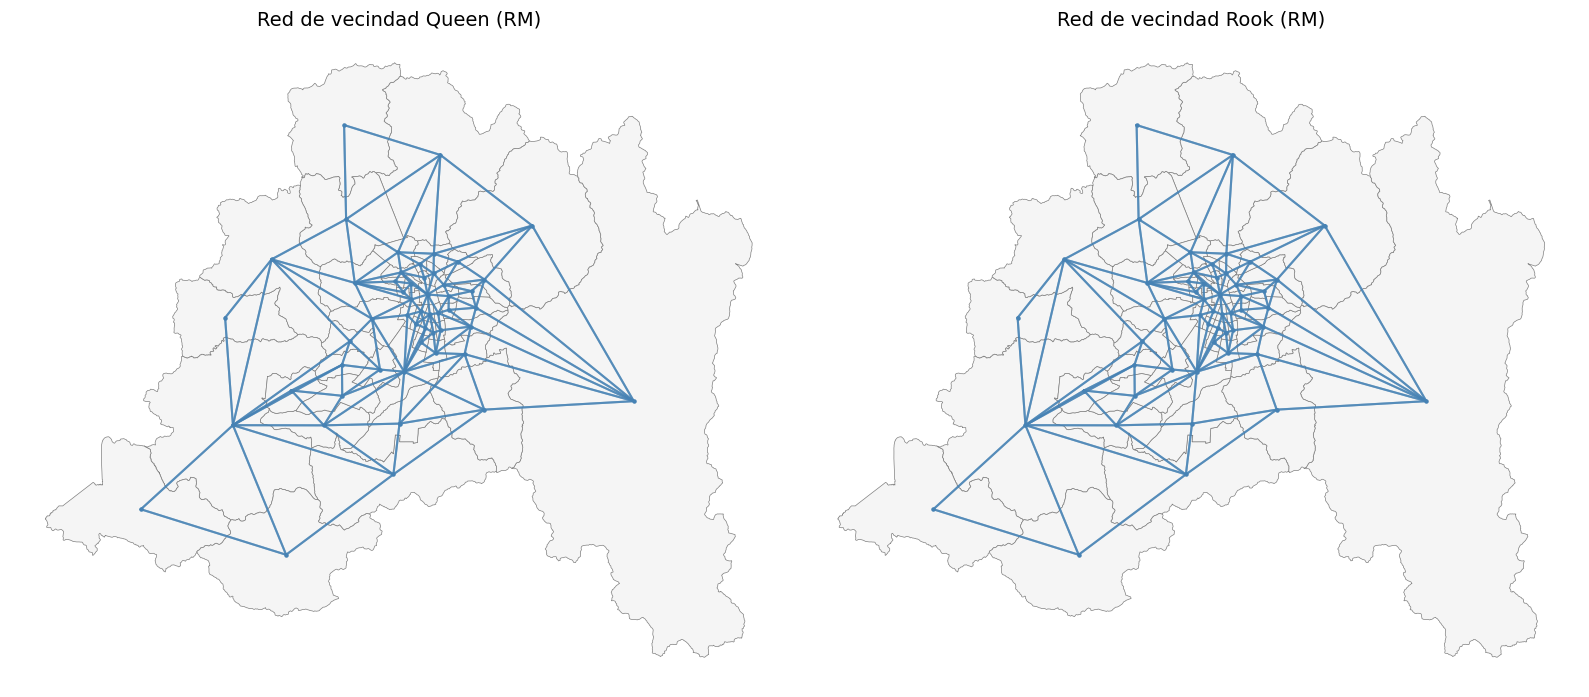


Queen:
  Grado promedio : 5.50
  Máximo vecinos : 12
  Mínimo vecinos : 2
  Islas          : []

Rook:
  Grado promedio : 5.35
  Máximo vecinos : 11
  Mínimo vecinos : 2
  Islas          : []


In [2]:
# Construir pesos Queen y Rook
w_queen = weights.contiguity.Queen.from_dataframe(rm_comunas, ids="NOM_COMUNA")
w_rook = weights.contiguity.Rook.from_dataframe(rm_comunas, ids="NOM_COMUNA")

# Visualización lado a lado
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

for ax, w, titulo in zip(axs, [w_queen, w_rook], ["Queen", "Rook"]):
    rm_comunas_idx.plot(ax=ax, edgecolor="grey", facecolor="whitesmoke", linewidth=0.5)
    w.plot(
        rm_comunas_idx, ax=ax,
        edge_kws=dict(color="steelblue", linewidth=1.5, alpha=0.7),
        node_kws=dict(marker="o", color="steelblue", s=5),
    )
    ax.set_title(f"Red de vecindad {titulo} (RM)", fontsize=14)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

# Estadísticas
for nombre, w in [("Queen", w_queen), ("Rook", w_rook)]:
    card = pd.Series(w.cardinalities)
    print(f"\n{nombre}:")
    print(f"  Grado promedio : {card.mean():.2f}")
    print(f"  Máximo vecinos : {card.max()}")
    print(f"  Mínimo vecinos : {card.min()}")
    print(f"  Islas          : {w.islands}")

### Parte B: Encontrar diferencias

In [3]:
# Encontrar pares que son vecinos Queen pero NO Rook
diferencias = {}
for comuna in w_queen.neighbors:
    solo_queen = set(w_queen.neighbors[comuna]) - set(w_rook.neighbors[comuna])
    if solo_queen:
        diferencias[comuna] = solo_queen

# Mostrar los primeros 5 casos
print("Comunas con vecinos Queen que NO son vecinos Rook:\n")
for i, (comuna, vecinos) in enumerate(diferencias.items()):
    if i >= 5:
        break
    print(f"  {comuna} → vecinos solo Queen: {vecinos}")

print(f"\nTotal de comunas con diferencias: {len(diferencias)}")

Comunas con vecinos Queen que NO son vecinos Rook:

  BUIN → vecinos solo Queen: {'PUENTE ALTO'}
  PEDRO AGUIRRE CERDA → vecinos solo Queen: {'LA CISTERNA'}
  LO ESPEJO → vecinos solo Queen: {'SAN MIGUEL'}
  LA CISTERNA → vecinos solo Queen: {'PEDRO AGUIRRE CERDA'}
  PUENTE ALTO → vecinos solo Queen: {'BUIN'}

Total de comunas con diferencias: 8


**Respuesta esperada:** Los vecinos que aparecen en Queen pero no en Rook son comunas que comparten solo un **vértice** (un punto de esquina) pero no una arista completa. Geométricamente, esto ocurre cuando las comunas se tocan "en diagonal", como las casillas de un tablero de ajedrez.

---
## Ejercicio 2 — La comuna más conectada (15 min)

### Parte A: ¿Quién tiene más vecinos?

In [5]:
# Construir KNN k=5
wk5 = weights.distance.KNN.from_dataframe(rm_comunas, k=5, ids="NOM_COMUNA")

# Encontrar la comuna con más vecinos en cada método
for nombre, w in [("Queen", w_queen), ("Rook", w_rook), ("KNN k=5", wk5)]:
    card = pd.Series(w.cardinalities)
    comuna_max = card.idxmax()
    n_max = card.max()
    vecinos = list(w.neighbors[comuna_max])
    print(f"\n{nombre}:")
    print(f"  Comuna: {comuna_max} ({n_max} vecinos)")
    print(f"  Vecinos: {vecinos}")


Queen:
  Comuna: SAN BERNARDO (12 vecinos)
  Vecinos: ['PIRQUE', 'CALERA DE TANGO', 'MAIPÚ', 'CERRILLOS', 'LO ESPEJO', 'LA PINTANA', 'ISLA DE MAIPO', 'LA CISTERNA', 'EL BOSQUE', 'TALAGANTE', 'BUIN', 'PUENTE ALTO']

Rook:
  Comuna: SAN BERNARDO (11 vecinos)
  Vecinos: ['CALERA DE TANGO', 'MAIPÚ', 'CERRILLOS', 'LO ESPEJO', 'LA PINTANA', 'ISLA DE MAIPO', 'LA CISTERNA', 'EL BOSQUE', 'TALAGANTE', 'BUIN', 'PUENTE ALTO']

KNN k=5:
  Comuna: PAINE (5 vecinos)
  Vecinos: [np.str_('BUIN'), np.str_('ISLA DE MAIPO'), np.str_('TALAGANTE'), np.str_('SAN BERNARDO'), np.str_('CALERA DE TANGO')]


### Parte B: Visualización

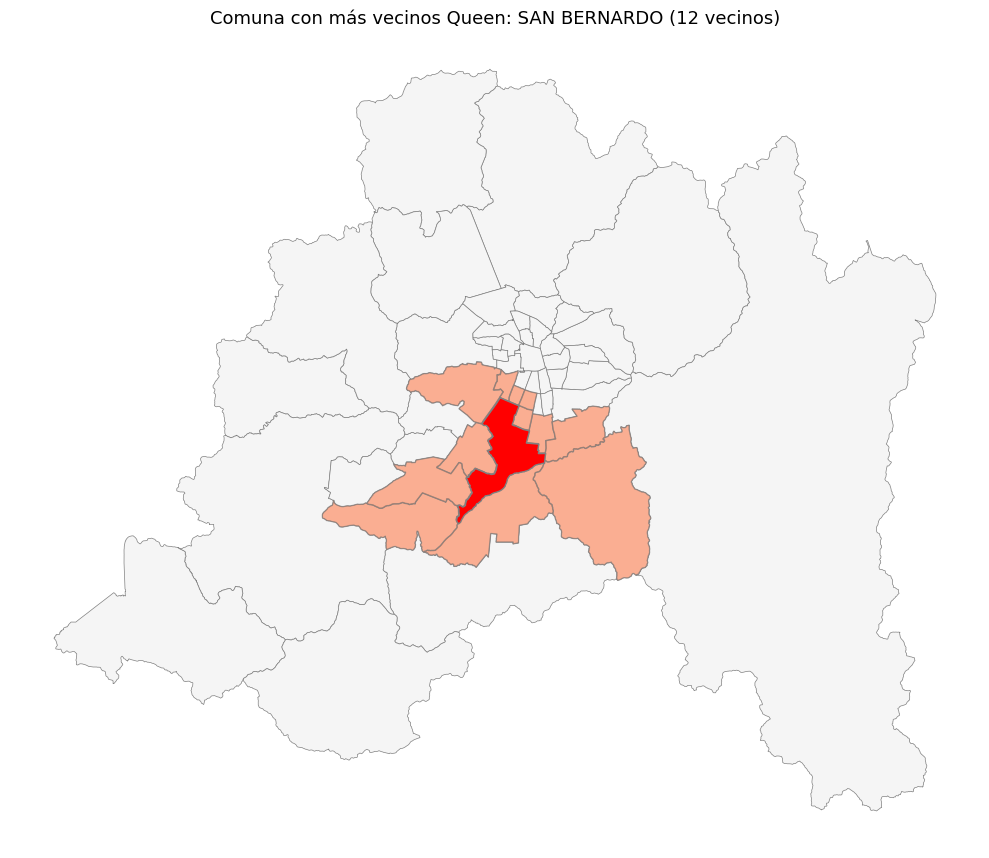

In [6]:
# Visualizar la comuna con más vecinos Queen
card_queen = pd.Series(w_queen.cardinalities)
comuna_max = card_queen.idxmax()
vecinos = list(w_queen.neighbors[comuna_max])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
rm_comunas_idx.plot(ax=ax, edgecolor="grey", facecolor="whitesmoke", linewidth=0.5)

# Vecinas en coral
rm_comunas_idx.loc[vecinos].plot(ax=ax, facecolor="coral", alpha=0.6, edgecolor="grey")

# Comuna focal en rojo
rm_comunas_idx.loc[[comuna_max]].plot(ax=ax, facecolor="red", edgecolor="grey")

ax.set_title(f"Comuna con más vecinos Queen: {comuna_max} ({card_queen.max()} vecinos)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Parte C: Interpretación

**Respuesta esperada:** Con KNN k=5, **todas** las comunas tienen exactamente 5 vecinos por construcción, así que el máximo es 5 para todas — no hay "más conectada". En cambio, Queen y Rook dependen de la geometría real: comunas grandes y centrales (que colindan con muchas otras) tendrán más vecinos. Esto muestra una diferencia fundamental: KNN impone una cardinalidad fija, mientras que contigüidad refleja la estructura geográfica real.

---
## Ejercicio 3 — DistanceBand y el problema de las islas (20 min)

### Parte A: Umbral de 10 km

In [7]:
# DistanceBand con umbral de 10.000 metros
w_db10 = weights.distance.DistanceBand.from_dataframe(
    rm_comunas, threshold=10000, binary=True, ids="NOM_COMUNA"
)

print(f"Número de islas: {len(w_db10.islands)}")
print(f"Comunas aisladas: {w_db10.islands}")

Número de islas: 15
Comunas aisladas: ['PAINE', 'BUIN', 'PUDAHUEL', 'COLINA', 'TILTIL', 'LAMPA', 'MARÍA PINTO', 'CURACAVÍ', 'LO BARNECHEA', 'MELIPILLA', 'SAN JOSÉ DE MAIPO', 'PIRQUE', 'EL MONTE', 'SAN PEDRO', 'ALHUÉ']


/Users/daniela/Documents/usm/cursos/geodata/.venv/lib/python3.11/site-packages/libpysal/weights/util.py:819: UserWarning: The weights matrix is not fully connected: 
 There are 16 disconnected components.
 There are 15 islands with ids: PAINE, BUIN, PUDAHUEL, COLINA, TILTIL, LAMPA, MARÍA PINTO, CURACAVÍ, LO BARNECHEA, MELIPILLA, SAN JOSÉ DE MAIPO, PIRQUE, EL MONTE, SAN PEDRO, ALHUÉ.
  w = W(neighbors, weights, ids, **kwargs)
/Users/daniela/Documents/usm/cursos/geodata/.venv/lib/python3.11/site-packages/libpysal/weights/distance.py:855: UserWarning: The weights matrix is not fully connected: 
 There are 16 disconnected components.
 There are 15 islands with ids: PAINE, BUIN, PUDAHUEL, COLINA, TILTIL, LAMPA, MARÍA PINTO, CURACAVÍ, LO BARNECHEA, MELIPILLA, SAN JOSÉ DE MAIPO, PIRQUE, EL MONTE, SAN PEDRO, ALHUÉ.
  W.__init__(


**Respuesta esperada:** Las comunas que quedan como islas son aquellas cuyos **centroides** están a más de 10 km del centroide más cercano. Típicamente son comunas cordilleranas o rurales de gran extensión territorial (como San José de Maipo, Alhué, etc.), donde los centroides quedan muy separados a pesar de que los polígonos podrían incluso tocarse. Esto ilustra una limitación de los métodos basados en distancia de centroides.

### Parte B: Encontrar el umbral mínimo

/Users/daniela/Documents/usm/cursos/geodata/.venv/lib/python3.11/site-packages/libpysal/weights/util.py:819: UserWarning: The weights matrix is not fully connected: 
 There are 15 disconnected components.
 There are 14 islands with ids: PAINE, BUIN, COLINA, TILTIL, LAMPA, MARÍA PINTO, CURACAVÍ, LO BARNECHEA, MELIPILLA, SAN JOSÉ DE MAIPO, PIRQUE, EL MONTE, SAN PEDRO, ALHUÉ.
  w = W(neighbors, weights, ids, **kwargs)
/Users/daniela/Documents/usm/cursos/geodata/.venv/lib/python3.11/site-packages/libpysal/weights/distance.py:855: UserWarning: The weights matrix is not fully connected: 
 There are 15 disconnected components.
 There are 14 islands with ids: PAINE, BUIN, COLINA, TILTIL, LAMPA, MARÍA PINTO, CURACAVÍ, LO BARNECHEA, MELIPILLA, SAN JOSÉ DE MAIPO, PIRQUE, EL MONTE, SAN PEDRO, ALHUÉ.
  W.__init__(
/Users/daniela/Documents/usm/cursos/geodata/.venv/lib/python3.11/site-packages/libpysal/weights/util.py:819: UserWarning: The weights matrix is not fully connected: 
 There are 13 disconn

Umbral mínimo sin islas: 39,000 metros (39 km)


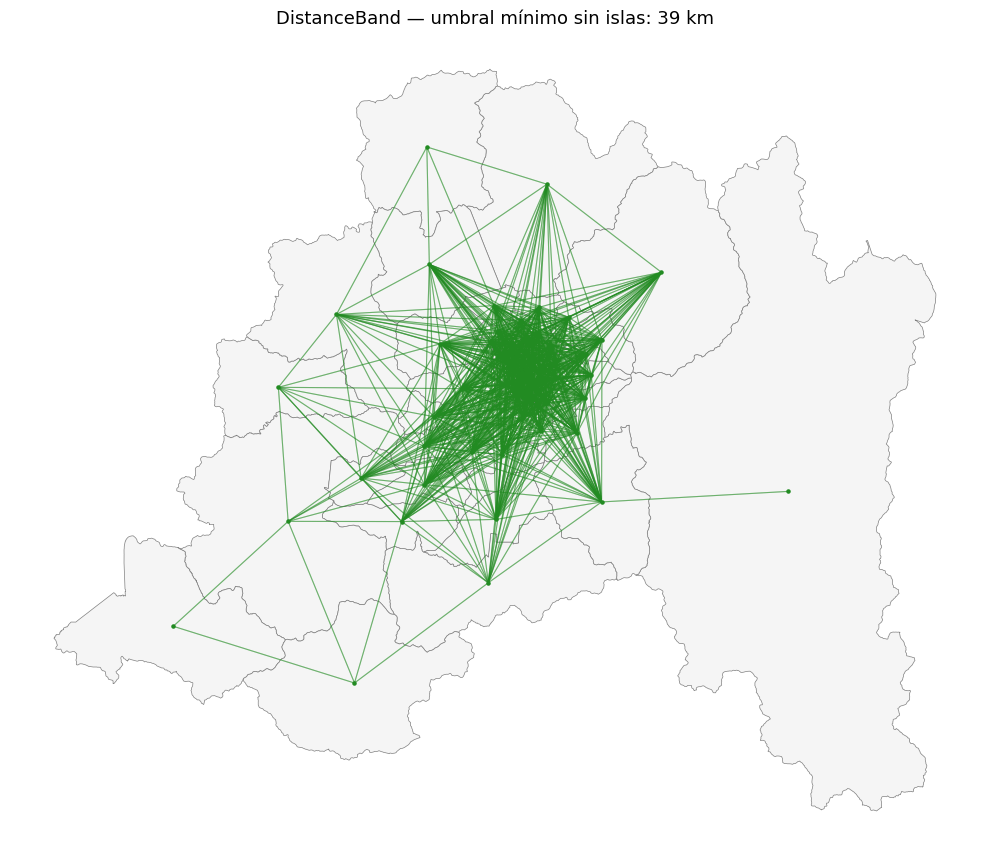

In [8]:
# Buscar el umbral mínimo que elimina todas las islas
for umbral in range(10000, 80000, 1000):
    w_test = weights.distance.DistanceBand.from_dataframe(
        rm_comunas, threshold=umbral, binary=True, ids="NOM_COMUNA"
    )
    if len(w_test.islands) == 0:
        print(f"Umbral mínimo sin islas: {umbral:,} metros ({umbral/1000:.0f} km)")
        break

# Visualizar el grafo con ese umbral
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
rm_comunas_idx.plot(ax=ax, edgecolor="grey", facecolor="whitesmoke", linewidth=0.5)
w_test.plot(
    rm_comunas_idx, ax=ax,
    edge_kws=dict(color="forestgreen", linewidth=0.8, alpha=0.4),
    node_kws=dict(marker="o", color="forestgreen", s=5),
)
ax.set_title(f"DistanceBand — umbral mínimo sin islas: {umbral/1000:.0f} km", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

---
## Ejercicio 4 — Tabla comparativa de síntesis (10 min)

In [9]:
# Construir todos los pesos necesarios
metodos = {
    "Queen": w_queen,
    "Rook": w_rook,
    "KNN k=5": wk5,
    "DistanceBand 10 km": w_db10,
}

# Tabla comparativa
filas = []
for nombre, w in metodos.items():
    card = pd.Series(w.cardinalities)
    filas.append({
        "Método": nombre,
        "n": w.n,
        "pct_nonzero": f"{w.pct_nonzero:.2f}%",
        "Tiene islas": "Sí" if w.islands else "No",
        "Card. promedio": f"{card.mean():.1f}",
    })

tabla = pd.DataFrame(filas).set_index("Método")
tabla

,n,pct_nonzero,Tiene islas,Card. promedio
Método,,,,
Queen,52,10.58%,No,5.5
Rook,52,10.28%,No,5.3
KNN k=5,52,9.62%,No,5.0
DistanceBand 10 km,52,13.54%,Sí,7.0


**Respuesta esperada para la pregunta de cierre:**

No hay una respuesta única "correcta", pero una buena respuesta debería considerar:

- **Queen** es la opción más conservadora y robusta para polígonos: captura toda la contigüidad (incluyendo vértices), no tiene islas, y refleja la geometría real. Es la elección más común en la literatura de análisis espacial con unidades administrativas.
- **Rook** es similar pero más restrictiva — puede perder relaciones relevantes.
- **KNN** es útil cuando se necesita cardinalidad fija, pero no refleja la geometría real y produce matrices asimétricas.
- **DistanceBand** puede generar islas si el umbral es bajo, y matrices muy densas si es alto. Requiere una elección de parámetro que no siempre es obvia.

Para datos socioeconómicos comunales, **Queen** suele ser la mejor opción por defecto.